# Model 1: Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


Matplotlib is building the font cache; this may take a moment.


### Load & Split Data

In [2]:
df = pd.read_csv('../data/final/ml_ready_dataset.csv')
X = df.select_dtypes(exclude=['object', 'string']).drop(columns=['is_returned'], errors='ignore')
y = df['is_returned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training size: {X_train.shape[0]} | Testing size: {X_test.shape[0]}")


Training size: 77599 | Testing size: 19400


### Feature Scaling & Class Weighting
Logistic Regression is distance-based, so scaling is mandatory. handle the 88/12 class imbalance natively by setting `class_weight='balanced'` in the algorithm, which mathematically penalizes the model heavier for missing minority class predictions.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete. Using native class weighting (class_weight='balanced') to handle imbalance.")


Feature scaling complete. Using native class weighting (class_weight='balanced') to handle imbalance.


### Model Training & Evaluation

In [4]:
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
lr = grid_search.best_estimator_

preds = lr.predict(X_test_scaled)
probs = lr.predict_proba(X_test_scaled)[:, 1]

print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validated ROC-AUC: {grid_search.best_score_:.4f}")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")


d:\pyhton3.14\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best Hyperparameters: {'C': 1.0, 'penalty': 'l2'}
Best Cross-Validated ROC-AUC: 0.8996

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.92     16517
           1       0.53      0.76      0.63      2883

    accuracy                           0.86     19400
   macro avg       0.74      0.82      0.77     19400
weighted avg       0.89      0.86      0.87     19400

ROC-AUC Score: 0.8968


### Model Conclusion: Logistic Regression
- **Overall Performance:** The model achieved an impressive **ROC-AUC of 0.8968**, meaning it has a very strong ability to separate safe orders from risky returns.

- **Business Impact (Recall):** With a **Recall of 76%** on class 1, the model successfully identifies over three-quarters of all actual returns.

- **Trade-off (Precision):** The precision is 53%, meaning when the model flags an order as a "Return", it is correct about half the time. Because we used `class_weight='balanced'`, the model was instructed to be aggressive in catching returns, which naturally results in some false alarms (false positives).

- **The "Ladder" Context:** While ~0.89 is a great baseline, we know that Logistic Regression struggles with the hidden categorical risks (like label-encoded cities and product categories). We expect Tree-based models to exceed this score.


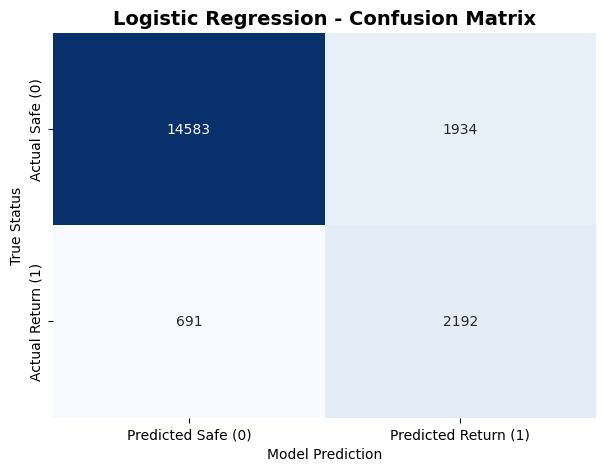

In [8]:
# Generate confusion matrix
cm = confusion_matrix(y_test, preds)
# Plot
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Safe (0)', 'Predicted Return (1)'],
            yticklabels=['Actual Safe (0)', 'Actual Return (1)'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Model Prediction')
plt.ylabel('True Status')
plt.show()


### Probability Analysis

#### Probability vs. Review Score

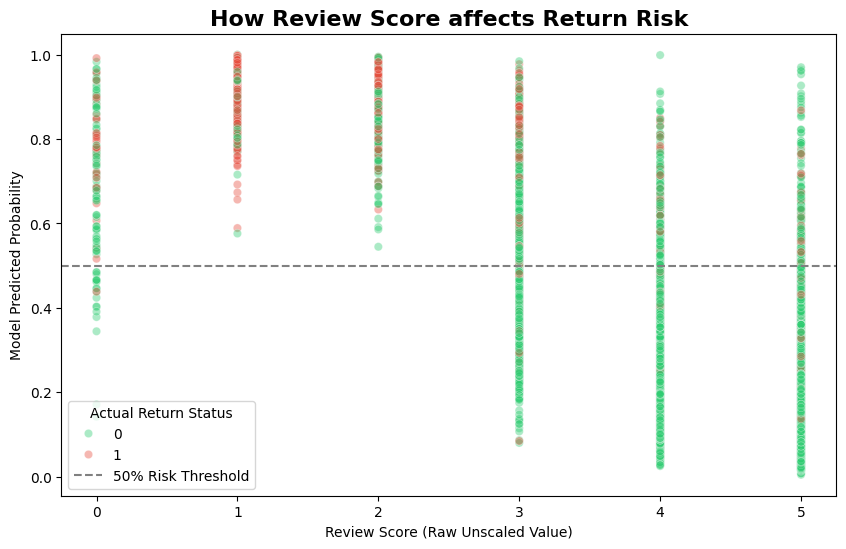

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['review_score'], y=probs, hue=y_test, palette=['#2ecc71', '#e74c3c'], alpha=0.4)
plt.title('How Review Score affects Return Risk', fontsize=16, fontweight='bold')
plt.xlabel('Review Score (Raw Unscaled Value)')
plt.ylabel('Model Predicted Probability')
plt.axhline(0.5, color='gray', linestyle='--', label='50% Risk Threshold')
plt.legend(title='Actual Return Status')
plt.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_14612\398121210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=X_test['review_score'], y=probs, palette='coolwarm', inner='quartile')


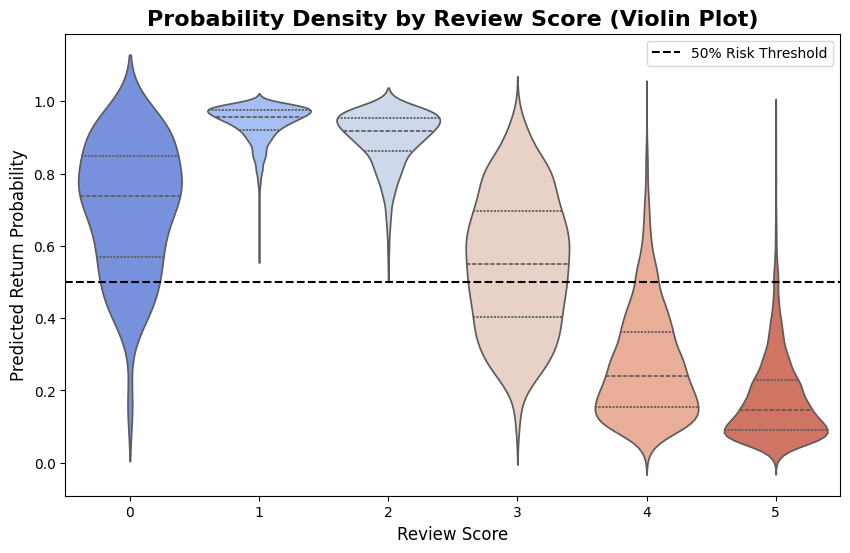

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=X_test['review_score'], y=probs, palette='coolwarm', inner='quartile')

plt.title('Probability Density by Review Score (Violin Plot)', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Predicted Return Probability', fontsize=12)
plt.axhline(0.5, color='black', linestyle='--', label='50% Risk Threshold')
plt.legend()
plt.show()


### Visualizing the Risk: Review Scores
- **The Linear Trend:** As expected from Logistic Regression, there is a clear, mathematical downward slope. Orders with 1-star reviews have predicted probabilities clustered heavily between 60% and 100%, safely above our 50% risk threshold. As the review score improves to 5-stars, the model's confidence in a return dropping the bulk of probabilities below 50%.
- **The Vertical Spread:** Notice how the dots stretch vertically at every single review score. This spread proves the model isn't *only* looking at reviews. For example, a 5-star order can still cross the 50% risk threshold if the model detects severe delivery delays or massive freight costs. 

#### Probability vs. Delivery Delay

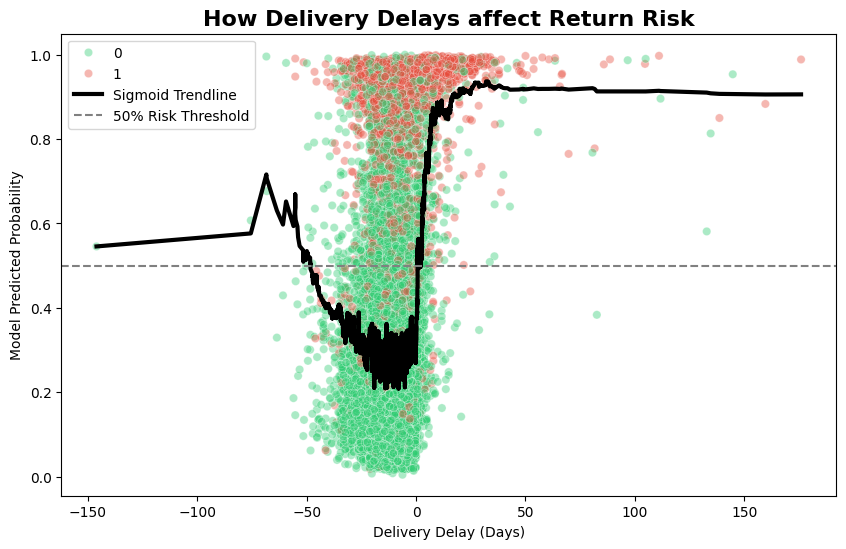

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['delivery_delay_days'], y=probs, hue=y_test, palette=['#2ecc71', '#e74c3c'], alpha=0.4)

temp = pd.DataFrame({'x': X_test['delivery_delay_days'], 'p': probs}).sort_values('x')
plt.plot(temp['x'], temp['p'].rolling(window=100, min_periods=1).mean(), color='black', linewidth=3, label='Sigmoid Trendline')

plt.title('How Delivery Delays affect Return Risk', fontsize=16, fontweight='bold')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Model Predicted Probability')
plt.axhline(0.5, color='gray', linestyle='--', label='50% Risk Threshold')
plt.legend()
plt.show()


 The black trendline perfectly illustrates the business reality we modeled. When packages arrive early (negative delay days on the left), the average return probability sits comfortably low (around 20-30%). But the exact moment a package becomes "Late" (crossing the 0-day mark on the x-axis), the risk violently spikes, shooting up to nearly 90%. 


### Interpreting the Model: Feature Coefficients
Which features push the model to predict a 'Return'?

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14612\839814213.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette="coolwarm")


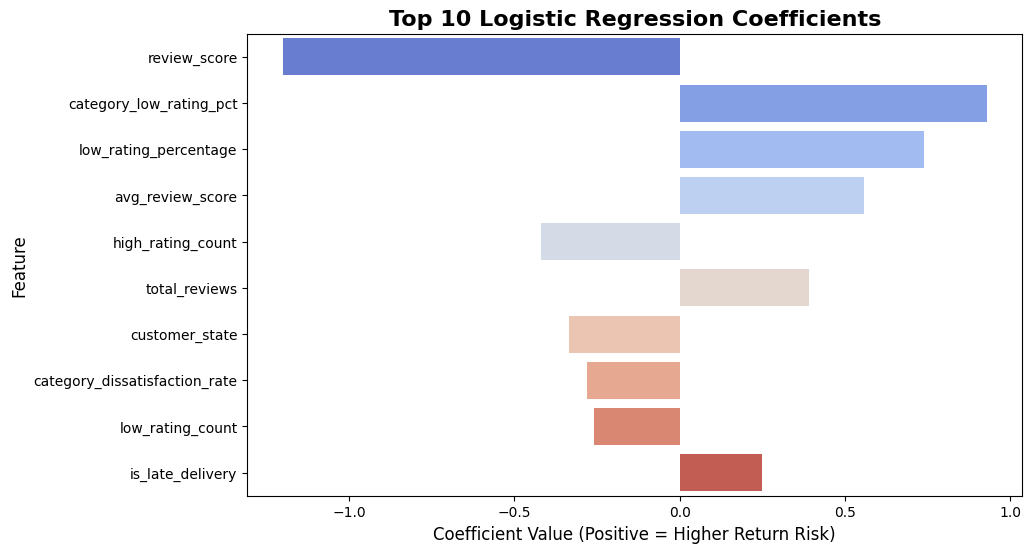

In [7]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coefficients['Abs_Coefficient'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Coefficient', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette="coolwarm")
plt.title('Top 10 Logistic Regression Coefficients', fontsize=16, fontweight='bold')
plt.xlabel('Coefficient Value (Positive = Higher Return Risk)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.show()


###  The Flaws of Linear Math

Looking at the top 10 coefficients reveals exactly how Logistic Regression thinks, and exposes its critical weaknesses:

1. **The Expected Logic:** `review_score` has a massive negative coefficient. This makes perfect sense: as the review score goes up, the return risk goes down. Similarly, `is_late_delivery` has a positive coefficient (late = higher risk).

2. **The Multicollinearity Trap:** Look at `avg_review_score`. It has a **positive** coefficient! This implies that products with better average reviews have *higher* return risks. Why did this happen? Because `review_score`, `low_rating_percentage`, and `avg_review_score` are highly correlated. Linear models get "confused" by multicollinearity and will arbitrarily flip signs to balance the mathematical equation, making the model incredibly unstable and unexplainable to business stakeholders.

3. **The Categorical Failure:** Notice `customer_state` has a negative coefficient of around -0.3. In our feature engineering, `customer_state` was label-encoded into arbitrary integers (e.g., SP = 25, RJ = 15). Logistic Regression is physically multiplying that integer by -0.3. It assumes that "State 25" is inherently safer than "State 15" just because 25 is a bigger number! This proves that Logistic Regression is entirely blinded to the categorical risks we injected.

### Next Steps
Logistic Regression gave us a solid 0.89 baseline, but its inability to handle correlated features and categorical integers means it has hit its mathematical ceiling. 

Let's move on to **Notebook 02: Decision Trees**, which handles categories and non-linear interactions natively!
